# Artificial Neural Netowrks

An **Artificial Neural Networs** (ANN) is a model inspired by the networks of biological neurons found in our brains. A neuron is a cell  found in animal brains. It’s composed of a **cell body** containing the **nucleus** and most of the cell’s complex components, many branching extensions called **dendrites**, plus one very long extension called the **axon**. The axon’s length may be just a few times longer than the cell body, or up to tens of thousands of times longer. Near its extremity the axon splits off into many branches called **telodendria**, and at the tip of these branches are minuscule structures called **synapses**, which are
connected to the dendrites or cell bodies of other neurons. 

<img src="images/biological-neuron.png" width="600">

Biological neurons produce short electrical impulses called **action potentials** which travel along the axons and make the synapses release chemical signals called **neurotransmitters**. When a neuron receives a sufficient amount of these neurotransmitters within a few milliseconds, it fires its own electrical impulses (actually, it depends on the neurotransmitters, as some of them inhibit the neuron from firing).

Thus, individual biological neurons seem to behave in a rather simple way, but they are organized in a vast network of billions, with each neuron typically connected to thousands of other neurons. Highly complex computations can be performed by a network of fairly simple neurons. The architecture of biological neural networks is still the subject of active research, but some parts of the brain have been mapped, and it seems that neurons are often organized in consecutive layers, especially in the cerebral cortex.

ANN are inspired by this networks of biological neurons, however ANNs have
gradually become quite different from their biological cousins. Some researchers even argue that we should drop the biological analogy altogether (e.g., by saying “units” rather than “neurons”), lest we restrict our creativity to biologically plausible systems.

## Perceptron

The Perceptron is one of the simplest ANN architectures, invented in 1957
by Frank Rosenblatt. It is based on a artificial neuron **linear threshold unit** (LTU). The inputs ($x$) and output ($y$) are numbers, and each input connection is associated with a weight ($w$). The neuron computes a weighted sum of its inputs: 

$z = w _1 x_1 + w_2 x_2 + ⋯ + w_n x_n = X^TW$

then applies a step function to that sum and outputs the result:

$y=f(z)=\text{step}(z)$

<img src="images/tlu.png" width="600">

The most common step function used is the **heaviside step function**, sometimes the **sign function** is used instead.

$\text{heaviside}(z) = 
\begin{cases}
    0 & \text{if} & z \lt 0 \\
    1 & \text{if} & z \gt 1
\end{cases}$

$\text{sgn}(z) = 
\begin{cases}
    -1 & \text{if} & z \lt 0 \\
     0 & \text{if} & z = 0 \\
     1 & \text{if} & z \gt 1
\end{cases}$

A single TLU can be used for simple linear binary classification. It computes a linear combination of the inputs, and if the result exceeds a threshold, it outputs the positive class. Otherwise it outputs the negative class (just like a Logistic Regression or linear SVM classifier). Training a TLU means finding the right values for $w_1$, $w_2$, ..., $w_n$.

A Perceptron is simply composed of a single layer of neurons, with each neuron connected to all the inputs. When all the neurons in a layer are connected to every neuron in the previous layer (i.e., its input neurons), the layer is called a **fully connected layer**, or **dense layer**.    XXXX   The inputs of the Perceptron are fed to special passthrough neurons called **input neurons**: they output whatever input they are fed. All the input neurons form the input
layer. Moreover, an extra bias feature is generally added ($x_0=1$): it is
typically represented using a special type of neuron called a **bias neuron**, which outputs 1 all the time. A Perceptron with two inputs and three outputs is represented in the following figure. This Perceptron can classify instances simultaneously into three different binary classes, which makes it a multioutput classifier.

<img src="images/perceptron.png" width="500">

$h_{W,b}=\phi(XW+b)$

where:
- X represents the matrix of input features, it has one row per instance and one column per feature;
- W is the weight matrix, it contains all the connection weights except for the ones from the bias neuron. It has one row per input neuron and one column per artificial neuron in the layer;
- b is the bias vector, it contains all the connection weights between the bias neuron and the artificial neurons. It has one bias term per artificial neuron;
- $\phi$ is the activation function: when the artificial neurons are TLUs, it is a step function.

In [5]:
import sys; sys.path.insert(0, '..')
from scratch.linear_algebra import Vector, dot

def step(z: float) -> float:
    return 1.0 if z >= 0 else 0.0

def perceptron(w: Vector, bias: float, x: Vector) -> float:
    z = dot(w, x) + bias
    return step(z)

With properly chosen weights, perceptrons can solve a number of simple problems. For example, we can create an AND gate with:

In [6]:
and_weights = [2., 2]
and_bias = -3.

print(perceptron(and_weights, and_bias, [1, 1]))
print(perceptron(and_weights, and_bias, [0, 1]))
print(perceptron(and_weights, and_bias, [1, 0]))
print(perceptron(and_weights, and_bias, [0, 0]))

1.0
0.0
0.0
0.0


Using similar reasoning, we could build an OR gate with:

In [7]:
or_weights = [2., 2]
or_bias = -1.

print(perceptron(or_weights, or_bias, [1, 1]))
print(perceptron(or_weights, or_bias, [0, 1]))
print(perceptron(or_weights, or_bias, [1, 0]))
print(perceptron(or_weights, or_bias, [0, 0]))

1.0
1.0
1.0
0.0


However, there are some problems that simply can’t be solved by a single perceptron. For example, no matter how hard you try, you cannot use a perceptron to build an XOR gate.

Perceptrons are trained taking into account the error made by the network when it makes a prediction: the learning rule **reinforces** connections that help reduce the error. More specifically, the Perceptron is fed one training
instance at a time, and for each instance it makes its predictions. For every
output neuron that produced a wrong prediction, it reinforces the connection
weights from the inputs that would have contributed to the correct prediction (**delta rule**):

$\boxed{w_{ij}=w_{ij}+\eta(y_j-t_j)x_i}$

where:
- $w_{ij}$ is the connection weight between the input neuron $i$ and the output neuron $j$;
- $x_i$ is the input value $i$ of the current training instance;
- $y_j$ is the output of the output neuron $j$ for the current training instance;
- $t_j$ is the target output of the output neuron $j$ for the current training instance;
- $\eta$ is the **learning rate**.

The decision boundary of each output neuron is linear, so Perceptrons are
incapable of learning complex patterns (just like Logistic Regression
classifiers). However, if the training instances are linearly separable,
Rosenblatt demonstrated that this algorithm would converge to a solution.
This is called the **Perceptron convergence theorem**.

Scikit-Learn provides a **Perceptron class** that implements a single-TLU
network:

In [9]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron

iris = load_iris()
X = iris.data[:, (2, 3)]  # petal length, petal width
y = (iris.target == 0).astype(int)

perceptron_clf = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron_clf.fit(X, y)

y_pred = perceptron_clf.predict([[2, 0.5]])
print(y_pred)

[1]


The Perceptron learning algorithm strongly resembles Stochastic Gradient Descent. In fact, Scikit-Learn’s Perceptron class is equivalent to using an SGDClassifier with the following hyperparameters: loss="perceptron", learning_rate="constant", eta0=1 (the learning rate), and penalty=None (no regularization). Note that contrary to Logistic Regression classifiers, Perceptrons do not output a class probability; rather, they make predictions based on a hard threshold. This is one reason to prefer Logistic Regression over Perceptrons.

## Multilayer Perceptron
A **Multilayer Perceptron** (MLP) is composed of one (passthrough) input layer, one or more layers of TLUs, called **hidden layers**, and one final layer of TLUs called the **output layer**. Note the signal flows only in one direction (from the inputs to the outputs), so this architecture is an example of a **feedforward neural network** (FNN).

<img src="images/mlp.png" width="500">

As with the perceptron, for each neuron we’ll sum up the products of its inputs and its weights. But here, rather than outputting the step function applied to that product, we’ll output a smooth approximation of it, like the sigmoid function:

In [10]:
import math

def sigmoid(z: float) -> float:
    return 1 / (1 + math.exp(-z))

(-10.0, 10.0, -0.2, 1.2)

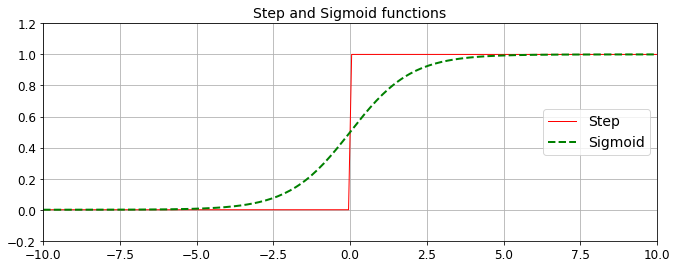

In [11]:
x = np.linspace(-10, 10, 200).tolist()
y_step =  [step(point) for point in x]
y_sigmoid =  [sigmoid(point) for point in x]

plt.figure(figsize=(11,4))
plt.plot(x, y_step, "r-", linewidth=1, label="Step")
plt.plot(x, y_sigmoid, "g--", linewidth=2, label="Sigmoid")
plt.grid(True)
plt.legend(loc="center right", fontsize=14)
plt.title("Step and Sigmoid functions", fontsize=14)
plt.axis([-10, 10, -0.2, 1.2])

Why use sigmoid instead of the simpler step function? In order to train a neural network, we need to use calculus, and in order to use calculus, we need smooth functions. Step function isn’t even continuous, and sigmoid is a good smooth approximation of it.

In [12]:
def neuron(w: Vector, x: Vector) -> float:
    # weights includes the bias term, inputs includes a 1
    return sigmoid(dot(w, x))

Given this function, we can represent a neuron simply as a vector of weights whose length is one more than the number of inputs to that neuron (because of the bias weight). Then we can represent a neural network as a list of (noninput) layers,
where each layer is just a list of the neurons in that layer.

That is, we’ll represent a neural network as a list (layers) of lists (neurons) of vectors (weights). Given such a representation, using the neural network is quite
simple:

In [13]:
from typing import List

def feed_forward(neural_network: List[List[Vector]], input_vector: Vector) -> List[Vector]:
    outputs: List[Vector] = []
    for layer in neural_network:
        input_with_bias = input_vector + [1]              
        output = [neuron(n, input_with_bias) for n in layer]               
        outputs.append(output)
        input_vector = output
    return outputs

Now, we cab build the XOR gate that we couldn’t build with a single perceptron:

In [14]:
xor_network = [# hidden layer
               [[20., 20, -30],      
                [20., 20, -10]],     
               # output layer
               [[-60., 60, -30]]]

print(feed_forward(xor_network, [0, 0])[-1][0])
print(feed_forward(xor_network, [1, 0])[-1][0])
print(feed_forward(xor_network, [0, 1])[-1][0])
print(feed_forward(xor_network, [1, 1])[-1][0])

9.38314668300676e-14
0.9999999999999059
0.9999999999999059
9.383146683006828e-14


One suggestive way of thinking about this is that the hidden layer is computing features of the input data and the output layer is combining those features in a way that generates the desired output.

Usually we don’t build neural networks by hand. This is in part because we use them to solve much bigger problems, and in part because we usually won’t be able to reason out what the neurons should be. Instead, we use data to train neural networks. The typical approach is an algorithm called backpropagation, which uses gradient descent or one of its variants.

## Backpropagation

Imagine we have a training set that consists of input vectors and corresponding target output vectors. Imagine that our network has some set of weights. [Backpropagation](https://www.3blue1brown.com/lessons/backpropagation-calculus), in just two passes through the network (one forward, one backward), is able to compute the gradient of the network’s error with regard to every single model parameter. In other words, it can find out how each connection weight and each bias term should be tweaked in order to reduce the error. Once it has these gradients, it just performs a regular Gradient Descent step, and the whole process is repeated until the network converges to the solution.

Let’s run through this algorithm in a bit more detail.

Backpropagation handles one mini-batch at a time, and it goes through the full training set multiple times. Each pass is called an **epoch**. Each mini-batch is passed to the network’s input layer, which sends it to the first hidden layer. The algorithm then computes the output of all the neurons in this layer (for every instance in the mini-batch). The result is passed on to the next layer, its output is computed and passed to the next layer, and so on until we get the output of the last layer, the output layer. This is **the forward pass**: it is exactly like making predictions, except all intermediate results are preserved since they are needed for the backward pass.

<img src="images/backpropagation-1.png" width="900">

Next, the algorithm measures the network’s output error (i.e., it uses a **loss function** that compares the desired output and the actual output of the network, and returns some measure of the error).

<img src="images/backpropagation-2.png" width="400">

It is impossible to compute error signal for internal neurons directly, becouse output values of these neurons are unknown. The idea is to propagate error signal back to all neurons, working backward until the algorithm reaches the input layer. The weights used to propagate back are equal to these used during the computation of the output value. Only the direction of the data flow is changed. This reverse pass efficiently measures the error gradient across all the connection weights in the network by propagating the error gradient backward through the network (hence the name of the algorithm).

<img src="images/backpropagation-3.png" width="900">

Finally, the algorithm performs a Gradient Descent step to tweak all the connection weights in the network, using the error gradients it just computed.
The rule used is actually similar to the conventional delta rule used for the perceptron, it updates the weights in proportion to the learning rate, the input to which the weight is applied, and the error in the output of the unit. The major difference is that the simple error term is replaced by
the more complex error term previously calculated. 

<img src="images/backpropagation-4.png" width="900">

In summary: for each training instance, the backpropagation algorithm first makes a prediction (forward pass) and measures the error, then goes through each layer in reverse to measure the error contribution from each connection (reverse pass), and finally tweaks the connection weights to reduce the error (Gradient Descent step).

Let's try to derive the backprogation training rule. Recall the notation:
- $x_{ij}$ is the input $i$ to unit $j$
- $w_{ij}$ is the weight associated with input $i$ to unit $j$
- $z_j$ is the weighted sum of input for unit $j$ $z_j=\sum\limits_{i}{w_{ij}x_{ij}}$
- $y_j$ is the output computeted by unit $j$ $y_j=f(z_j)$
- $t_j$ is the target value of the output unit $j$

We start from the **stochastic gradient descent** rule, which involves iterating through the examples in the training set, for each training example descending the gradient of the error function with respect to this example. More specifically, for each example, every weight $w_{ij}$ is updated by adding to it the value $\Delta w_{ij}$:

$\begin{align}
\Delta w_{ij}=-\eta \frac{\partial J}{\partial w_{ij}}
\end{align}$      (1)

where $J$ is the error on the training example, summed over all output units ($O$) in the output layer of the network:

$\begin{align}
J=\frac{1}{2}\sum\limits_{k\epsilon O}{(t_k-y_k)^2}
\end{align}$

Let us now derive the partial derivative term in the gradient descent rule. Notice that weight $w_{ij}$ can influence the network output only through $y_j$. Using the chain rule we can write:

$\begin{align}
\frac{\partial J}{\partial w_{ij}}=\frac{\partial J}{\partial z_j}\frac{\partial z_j}{\partial w_{ij}}=\frac{\partial J}{\partial z_j}x_{ij}=\delta_jx_{ij}
\end{align}$     (2)

we can substitute (2) in (1):

$\begin{align}
\boxed{\Delta w_{ij}=-\eta\delta_jx_{ij}}
\end{align}$     

the input $x_{ij}$ of an input unit is the input $x_i$ and of an internal or output units is the output $y_i$ of the previous layer.

Our objective is now to derive the $\delta_j$ term. We can consider two different case: the case for an output unit and the case for an internal unit.

**Case 1, output unit**

Using the chain rule again we obtain:

$\begin{align}
\delta_j=\frac{\partial J}{\partial z_j}=\frac{\partial J}{\partial y_j}\frac{\partial y_j}{\partial z_j}=\frac{\partial J}{\partial y_j}y_j(1-y_j)
\end{align}$     (3)

notice that the derivative of $y_j$ is just the derivative of the activation function. In order for this algorithm to work properly, we need to replace the step function with the logistic function( **sigmoid**). This was essential because the step function contains only flat segments, so there is no gradient to work with, while the logistic function has a well-defined nonzero derivative everywhere.

$\begin{align}
\sigma (x) = \frac{1}{1+e^{-x}}
\end{align}$

$\begin{align}
\frac{d\sigma (x)}{d(x)} = \sigma (x)\cdot (1-\sigma(x))
\end{align}$

we now proceed with finding the last derivative:

$\begin{align}
\frac{\partial J}{\partial y_j}=\frac{\partial}{\partial y_j}\frac{1}{2}\sum\limits_{k\epsilon O}{(t_k-y_k)^2}=\frac{\partial}{\partial y_j}\frac{1}{2}(t_j-y_j)^2=\frac{1}{2}2(t_j-y_j)\frac{\partial}{\partial y_j}(t_j-y_j)=-(t_j-y_j)
\end{align}$     (4)

the summation term over output units is dropped because the derivatives is zero for all output units except for the case when $k=j$. By substituting (4) into (3) we obtain:

$\begin{align}
\boxed{\delta_j=-(t_j-y_j)y_j(1-y_j)}
\end{align}$

**Case 2, internal unit**

When unit $j$ is internal, we must also consider every unit immediately downstream of it (all units whose direct input include the output that unit). This is because a change in $w_{ji}$ (through $z_j$) influences the network outputs through these units. Let $ds(j)$ denote units downstream of unit $j$, then:

$\begin{align}
\delta_j=\frac{\partial J}{\partial z_j}=\sum\limits_{k\epsilon ds(j)} \frac{\partial J}{\partial z_k}\frac{\partial z_k}{\partial z_j}=\sum\limits_{k\epsilon ds(j)}\delta _k \frac{\partial z_k}{\partial y_j}\frac{\partial y_j}{\partial z_j}=\sum\limits_{k\epsilon ds(j)}\delta_kw_{jk}y_j(1-y_j)  
\end{align}$

$\begin{align}
\boxed{\delta_j=y_j(1-y_j)\sum\limits_{k\epsilon ds(j)}\delta_kw_{jk}}
\end{align}$


It is important to initialize all the connection weights randomly, or else training will fail. For example, if we initialize all weights and biases to zero, then all neurons in a given layer will be perfectly identical, and thus backpropagation will affect them in exactly the same way, so they will remain identical. If instead we randomly initialize the weights, we break the symmetry and allow backpropagation to train a diverse team of neurons.

Let’s write a function to compute the gradients:

In [15]:
def sqerror_gradients(network: List[List[Vector]], input_vector: Vector, target_vector: Vector) -> List[List[Vector]]:
    """
    Given a neural network, an input vector, and a target vector,
    make a prediction and compute the gradient of the squared error
    loss with respect to the neuron weights.
    """
    # forward pass
    hidden_outputs, outputs = feed_forward(network, input_vector)

    # gradients with respect to output neuron pre-activation outputs
    output_deltas = [output * (1 - output) * (output - target)
                     for output, target in zip(outputs, target_vector)]

    # gradients with respect to output neuron weights
    output_grads = [[output_deltas[i] * hidden_output
                     for hidden_output in hidden_outputs + [1]]
                     for i, output_neuron in enumerate(network[-1])]

    # gradients with respect to hidden neuron pre-activation outputs
    hidden_deltas = [hidden_output * (1 - hidden_output) *
                     dot(output_deltas, [n[i] for n in network[-1]])
                     for i, hidden_output in enumerate(hidden_outputs)]

    # gradients with respect to hidden neuron weights
    hidden_grads = [[hidden_deltas[i] * input for input in input_vector + [1]]
                    for i, hidden_neuron in enumerate(network[0])]

    return [hidden_grads, output_grads]

As usual, we can train it using gradient descent

In [16]:
from scratch.gradient_descent import gradient_step
import tqdm
    
def train(network: List[List[Vector]], xs: Vector, ys: Vector, epochs: int, learning_rate: float) -> List[List[Vector]]:
    for epoch in tqdm.trange(epochs, desc="Neural network for xor"):
        for x, y in zip(xs, ys):
            gradients = sqerror_gradients(network, x, y)
            # Take a gradient step for each neuron in each layer
            network = [[gradient_step(neuron, grad, -learning_rate)
                        for neuron, grad in zip(layer, layer_grad)]
                        for layer, layer_grad in zip(network, gradients)]
    return network;

Let’s try to learn the XOR network we previously designed by hand. We start by generating the training data and initializing our neural network with random weights:

In [17]:
import random
random.seed(0)
    
# training data
xs = [[0., 0], [0., 1], [1., 0], [1., 1]]
ys = [[0.], [1.], [1.], [0.]]
    
# start with random weights
network = [ # hidden layer: 2 inputs -> 2 outputs
            [[random.random() for _ in range(2 + 1)],   # 1st hidden neuron
             [random.random() for _ in range(2 + 1)]],  # 2nd hidden neuron
            # output layer: 2 inputs -> 1 output
            [[random.random() for _ in range(2 + 1)]]   # 1st output neuron
          ]

In [18]:
learning_rate = 1.0
epochs = 2000;
network = train(network, xs, ys, epochs, learning_rate);

Neural network for xor: 100%|██████████| 2000/2000 [00:00<00:00, 14412.20it/s]


In [19]:
print(feed_forward(network, [0, 0])[-1][0])
print(feed_forward(network, [0, 1])[-1][0])
print(feed_forward(network, [1, 0])[-1][0])
print(feed_forward(network, [1, 1])[-1][0])

0.034333804574649227
0.9695399969539419
0.969456050523935
0.03202405432763502


## Activation Functions
The backpropagation algorithm works well with many other activation functions, not just the logistic function. Here are two other popular choices:

The **hyperbolic tangent function** is a S-shaped, continuous and differentiable, but its output value ranges from –1 to 1 (instead of 0 to 1 in the case of the logistic function). That range tends to make each layer’s output more or less centered around 0 at the beginning of training, which often helps speed up convergence.

The **Rectified Linear Unit (ReLU) function** is continuous but unfortunately not differentiable at $x=0$ (the slope changes abruptly, which can make Gradient Descent bounce around), and its derivative is 0 for $z<0$. In practice, however, it works very well and has the advantage of being fast to compute, so it has become the default.

In [20]:
def sign(x):
    return np.sign(x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def derivative(f, x, eps=0.000001):
    return (f(x + eps) - f(x - eps))/(2 * eps)

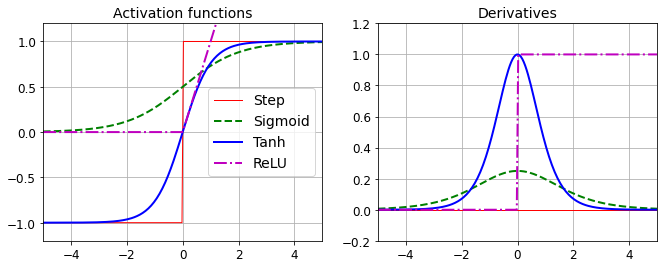

In [21]:
x = np.linspace(-5, 5, 200)

plt.figure(figsize=(11,4))

plt.subplot(121)
plt.plot(x, sign(x), "r-", linewidth=1, label="Step")
plt.plot(x, sigmoid(x), "g--", linewidth=2, label="Sigmoid")
plt.plot(x, tanh(x), "b-", linewidth=2, label="Tanh")
plt.plot(x, relu(x), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
plt.legend(loc="center right", fontsize=14)
plt.title("Activation functions", fontsize=14)
plt.axis([-5, 5, -1.2, 1.2])

plt.subplot(122)
plt.plot(x, derivative(sign, x), "r-", linewidth=1, label="Step")
plt.plot(x, derivative(sigmoid, x), "g--", linewidth=2, label="Sigmoid")
plt.plot(x, derivative(tanh, x), "b-", linewidth=2, label="Tanh")
plt.plot(x, derivative(relu, x), "m-.", linewidth=2, label="ReLU")
plt.grid(True)
plt.title("Derivatives", fontsize=14)
plt.axis([-5, 5, -0.2, 1.2])

plt.show()

Why do we need activation functions? Well, if we chain several linear transformations, all we get is a linear transformation. For example, if $f(x)=2x+3$ and $g(x)=5x–1$, then chaining these two linear functions gives us another linear function: $f(g(x))=2(5x–1)+3=10x+1$. So if we don’t have some nonlinearity between layers, then even a deep stack of layers is equivalent to a single
layer, and we can’t solve very complex problems with that. Conversely, a large enough ANN with nonlinear activations can theoretically approximate any continuous function.

## Regression and Classification

First, MLPs can be used for regression tasks. If you want to predict a single value (e.g., the price of a house, given many of its features), then you just need a single output neuron: its output is the predicted value. For multivariate regression (i.e., to predict multiple values at once), you need one output neuron per output dimension. 
For example, to locate the center of an object in an image, you need to predict 2D coordinates, so you need two output neurons. If you also want to place a bounding box around theo bject, then you need two more numbers: the width and the height of the object. So, you end up with four output neurons.
In general, when building an MLP for regression, you do not want to use any activation function for the output neurons, so they are free to output any range of values. If you want to guarantee that the output will always be positive, then you can use the ReLU activation function in the output layer. Finally, if you want to guarantee that the predictions will fall within a given range of values, then you can use the logistic function or the hyperbolic tangent, and then scale the labels to the appropriate range.
The loss function to use during training is typically the mean squared error, but if you have a lot of outliers in the training set, you may prefer to use the mean absolute error instead. Alternatively, you can use the **Huber loss**, which is a combination of both: it is quadratic when the error is smaller than a threshold, but linear when the error is larger than that. The linear part makes it less sensitive to outliers than the mean squared error, and the quadratic part allows it to converge faster and be more precise than the mean absolute error.
The following are the typical hyperparameters of a regression MLP architecture:
- number of input neurons: one per input feature (e.g. 28x28 for MNIST)
- number of hidden layers: depends on the problem, typically 1 to 5
- number of neurons per hidden layer: depends on the problem, typically 10 to 100
- number of output neurons: 1 per prediction dimension
- hidden activation function: ReLU
- output activation function: ReLU, Logistic or Tanh
- loss function: MSE ore Huber (if outliers)

MLPs can also be used for classification tasks. For a binary classification problem, you just need a single output neuron using the logistic activation function: the output will be a number between 0 and 1, which you can interpret as the estimated probability of the positive class. The estimated probability of the negative class is equal to one minus that number. MLPs can also easily handle multilabel binary classification tasks: you would dedicate one output neuron for each positive class.  For example, you could have an email classification system that predicts whether each incoming email is ham or spam, and simultaneously predicts whether it is an urgent or nonurgent email. In this case, you would need two output neurons, both using the logistic activation function: the first would output the probability that the email is spam, and the second would output the probability that it is urgent. 
Note that the output probabilities do not necessarily add up to 1. This lets the model output any combination of labels: you can have nonurgent ham, urgent ham, nonurgent spam, and perhaps even urgent spam (although that would probably be an error).
If each instance can belong only to a single class, out of three or more possible classes (e.g., classes 0 through 9 for digit image classification), then you need to have one output neuron per class, and you should use the softmax activation function for the whole output layer. The softmax function will ensure that all the estimated probabilities are between 0 and 1 and that they add up to 1 (which is required if the classes are exclusive). This is called multiclass classification.
Regarding the loss function, since we are predicting probability distributions, the cross-entropy loss is generally a good choice.
The following are the typical hyperparameters of a classification MLP architecture:
- number of input neurons: one per input feature (e.g. 28x28 for MNIST)
- number of hidden layers: depends on the problem, typically 1 to 5
- number of neurons per hidden layer: depends on the problem, typically 10 to 100
- number of output neurons: 1 (binary classification), 1 per label (multilabel binary), 1 per class (multiclass)
- hidden activation function: ReLU
- output activation function: Logistic (binary and multilabel) Softmax (multiclass)
- loss function: cross entropy

## Tuning Hyperparameters

The flexibility of SNN is also one of their main drawbacks: there are many hyperparameters to tweak. We can change the number of layers, the number of neurons per layer, the type of activation function to use in each layer, the weight initialization logic, and much more. 

How do we know what combination of hyperparameters is the best for our task? One option is to simply try many combinations of hyperparameters and see which one works best on the validation set (or use K-fold cross-validation). 

However, it  helps to have an idea of what values are reasonable for each hyperparameter so that we can build a quick prototype and restrict the search space. The following sections provide guidelines for choosing the number of hidden layers and neurons in an MLP and for selecting good values for some of the main hyperparameters.

For a review of best practices regarding tuning neural network hyperparameters, check out this excellent paper [A Disciplined Approach to Neural Network Hyperparameters](https://arxiv.org/abs/1803.09820)

### Number of Hidden Layers
For many problems, you can begin with a single hidden layer and get reasonable results. An MLP with just one hidden layer can theoretically model even the most complex functions, provided it has enough neurons. But for complex problems, **deep networks have a much higher parameter efficiency than shallow ones**: they can model complex functions using exponentially fewer neurons than shallow nets, allowing them to reach much better performance with the same amount of training data. The reason is that real-world data is often structured in a hierarchical way, and deep neural networks automatically take advantage of this fact: lower hidden layers model low-level structures (e.g., line segments of various shapes and orientations), intermediate hidden layers combine these low-level structures to model intermediate-level structures (e.g., squares, circles), and the highest hidden layers and the output layer combine these intermediate structures to model high-level structures (e.g., faces). This also improves the ability of deeper network to generalize well to new datasets. For example, if you have already trained a model to recognize faces in pictures and you now want to train a new neural network to recognize hairstyles, you can kickstart the training by reusing the lower layers of the first network. This way the network will not have to learn from scratch all the low-level structures, it will only have to learn the higher-level structures. This is called **transfer learning**.
In summary, for many problems you can start with just one or two hidden
layers, for more complex problems, you can ramp up the number of hidden layers until you start overfitting the training set.
Very complex tasks, such as large image classification or speech recognition, typically require networks with dozens of layers (or even hundreds) and they need a huge amount of training data. We will rarely have to train such networks from scratch: it is much more common to reuse parts of a pretrained state-of-the-art network that performs a similar task.

### Number of Neurons per Hidden Layer
The number of neurons in the input and output layers is determined by the type of input and output your task requires.  As for the hidden layers, it used to be common to size them to form a pyramid, with fewer and fewer neurons at each layer—the rationale being that many low-level features can coalesce into far fewer high-level features. However, this practice has been largely abandoned because it seems that using the same number of neurons in all hidden layers performs just as well in most cases, or even better; plus, there is only one hyperparameter to tune, instead of one per layer. That said, depending on the dataset, it can sometimes help to make the first hidden layer bigger than the others.
Just like the number of layers, you can try increasing the number of neurons gradually until the network starts overfitting. But in practice, it’s often simpler and more efficient to pick a model with more layers and neurons than you actually need, then use early stopping and other regularization techniques to prevent it from overfitting.
We can adopt the **stretch pants approach**: instead of wasting time looking for pants that perfectly match your size, just use large stretch pants that will shrink down to the right size.
Anywaym, in general it is better to increase the number of layers instead of the number of neurons per layer.

### Learning rate
The learning rate is arguably the most important hyperparameter. In general, the optimal learning rate is about half of the maximum learning rate (i.e., the learning rate above which the training algorithm diverges). One way to find a good learning rate is to train the model for a few hundred iterations, starting with a very low learning rate (e.g., $10^-5$ ) and gradually increasing it up to a very large value (e.g., 10). This is done by multiplying the learning rate by a constant factor at each iteration. If we plot the loss as a function of the learning rate, we should see it dropping at first. But after a while, the learning rate will be too large, so the loss will shoo back up: the optimal learning rate will be a bit lower than the point at which the loss starts to climb (typically about 10 times lower than the turning point). You can then reinitialize your model and train it
normally using this good learning rate.
Anyway, the optimal learning rate depends on the other hyperparameters (especially the batch size) so if you modify any hyperparameter, make sure to update the learning rate as well.

### Optimizer
Choosing a better optimizer than plain old Mini-batch Gradient Descent
is also quite important. We will see several advanced optimizers in more advanced topic.

### Batch size
The batch size can have a significant impact on our model’s performance and training time. The main benefit of using large batch sizes is that hardware accelerators (like GPUs) can process them efficiently. Therefore, many researchers and practitioners recommend using the largest batch size that can fit in GPU RAM. However, large batch sizes often lead to training instabilities, especially at the beginning of training, and the resulting model may not generalize as well as a model trained with a small batch size. 
A possible strategy is to try to use a large batch size, using learning rate warmup, and if training is unstable or the final performance is disappointing, then try using a small batch size instead.

### Activation function
In general, the ReLU activation function will be a good default for all hidden layers. For the output layer, it really depends on the task.

### Number of iterations
In most cases, the number of training iterations does not actually need to
be tweaked: just use early stopping instead.

## From Scratch

Previously, we built a simple neural network that allowed us to stack two layers of neurons, each of which computed sigmoid(dot(weights, inputs)). Although that’s perhaps an idealized representation of what an actual neuron does, in practice we’d like to allow a wider variety of things. Perhaps we’d like the neurons to remember something about their previous inputs. Perhaps we’d like to use a different activation function than sigmoid. And frequently we’d like
to use more than two layers. 

Before to introduce Keras (a powerful opensource library), we’ll build from scratch the machinery for implementing such a variety of neural networks. Our fundamental abstraction will be the Layer, something that knows how to apply some function to its inputs and that knows how to backpropagate gradients.

One way of thinking about the neural networks we built previously is as a "linear" layer, followed by a "sigmoid" layer, then another linear layer and another sigmoid layer.

We can define a general class to manage a layer:

In [22]:
from typing import Iterable, Tuple
from scratch.linear_algebra import Tensor

class Layer:
    """
    Our neural networks will be composed of Layers, each of which
    knows how to do some computation on its inputs in the "forward"
    direction and propagate gradients in the "backward" direction.
    """
    def forward(self, input):
        """
        Note the lack of types. We're not going to be prescriptive
        about what kinds of inputs layers can take and what kinds
        of outputs they can return.
        """
        raise NotImplementedError

    def backward(self, gradient):
        """
        Similarly, we're not going to be prescriptive about what the
        gradient looks like. It's up to you the user to make sure
        that you're doing things sensibly.
        """
        raise NotImplementedError

    def params(self) -> Iterable[Tensor]:
        """
        Returns the parameters of this layer. The default implementation
        returns nothing, so that if you have a layer with no parameters
        you don't have to implement this.
        """
        return ()

    def grads(self) -> Iterable[Tensor]:
        """
        Returns the gradients, in the same order as params()
        """
        return ()


The "forward" and "backward" methods will have to be implemented in our concrete subclasses. Once we build a neural net, we’ll want to train it using gradient descent, which means we’ll want to update each parameter in the network using its gradient. Accordingly, we insist that each layer be able to tell us its parameters and gradients.

Some layers (for example, a layer that applies sigmoid to each of its inputs) have no parameters to update.

In [24]:
from scratch.linear_algebra import Tensor, tensor_apply, tensor_combine

class Sigmoid(Layer):
    def forward(self, input: Tensor) -> Tensor:
        """
        Apply sigmoid to each element of the input tensor,
        and save the results to use in backpropagation.
        """
        self.sigmoids = tensor_apply(sigmoid, input)
        return self.sigmoids

    def backward(self, gradient: Tensor) -> Tensor:
        return tensor_combine(lambda sig, grad: sig * (1 - sig) * grad,
                              self.sigmoids,
                              gradient)

During the forward pass we saved the computed sigmoids so that we could use them later in the backward pass. The sig * (1 - sig) * grad comes from the chain rule from calculus and corresponds to the output * (1 - output) * (output - target) term.

In larger networks a popular replacement for the sigmoid is Relu:

In [36]:
class Relu(Layer):
    def forward(self, input: Tensor) -> Tensor:
        self.input = input
        return tensor_apply(lambda x: max(x, 0), input)

    def backward(self, gradient: Tensor) -> Tensor:
        return tensor_combine(lambda x, grad: grad if x > 0 else 0,
                              self.input,
                              gradient)

Now, we implement the "linear" layer that represents the dot(weights, inputs) part of the neurons. This layer has parameters, which we initialize with random values. It turns out that the initial parameter values can make a huge difference in how quickly (and sometimes whether) the network trains. If weights are too big, they may produce large outputs in a range where the activation function has near-zero gradients. And parts of the network that have zero gradients necessarily can’t learn anything via gradient descent. Accordingly, we’ll implement two different schemes for randomly generating our weight tensors. The first is to choose each value from the random uniform distribution on (0, 1). The second is to choose each value randomly from a standard normal distribution.

In [72]:
import random

from scratch.probability import inverse_normal_cdf

def random_uniform(*dims: int) -> Tensor:
    if len(dims) == 1:
        return [random.random() for _ in range(dims[0])]
    else:
        return [random_uniform(*dims[1:]) for _ in range(dims[0])]

def random_normal(*dims: int, mean: float = 0.0, variance: float = 1.0) -> Tensor:
    if len(dims) == 1:
        return [mean + variance * inverse_normal_cdf(random.random()) for _ in range(dims[0])]
    else:
        return [random_normal(*dims[1:], mean=mean, variance=variance) for _ in range(dims[0])]

def random_tensor(*dims: int, init: str = 'normal') -> Tensor:
    if init == 'normal':
        return random_normal(*dims)
    elif init == 'uniform':
        return random_uniform(*dims)
    else:
        raise ValueError(f"unknown init: {init}")

In [26]:
from scratch.linear_algebra import dot

class Linear(Layer):
    def __init__(self, input_dim: int, output_dim: int, init: str = 'normal') -> None:
        """
        A layer of output_dim neurons, each with input_dim weights
        (and a bias).
        """
        self.input_dim = input_dim
        self.output_dim = output_dim

        # self.w[o] is the weights for the o-th neuron
        self.w = random_tensor(output_dim, input_dim, init=init)

        # self.b[o] is the bias term for the o-th neuron
        self.b = random_tensor(output_dim, init=init)

    def forward(self, input: Tensor) -> Tensor:
        # Save the input to use in the backward pass.
        self.input = input

        # Return the vector of neuron outputs.
        return [dot(input, self.w[o]) + self.b[o] for o in range(self.output_dim)]

    def backward(self, gradient: Tensor) -> Tensor:
        # Each b[o] gets added to output[o], which means
        # the gradient of b is the same as the output gradient.
        self.b_grad = gradient

        # Each w[o][i] multiplies input[i] and gets added to output[o].
        # So its gradient is input[i] * gradient[o].
        self.w_grad = [[self.input[i] * gradient[o] 
                        for i in range(self.input_dim)]
                        for o in range(self.output_dim)]

        # Each input[i] multiplies every w[o][i] and gets added to every
        # output[o]. So its gradient is the sum of w[o][i] * gradient[o]
        # across all the outputs.
        return [sum(self.w[o][i] * gradient[o] 
                for o in range(self.output_dim))
                for i in range(self.input_dim)]

    def params(self) -> Iterable[Tensor]:
        return [self.w, self.b]

    def grads(self) -> Iterable[Tensor]:
        return [self.w_grad, self.b_grad]

In a real library, the operations written before would be represented as matrix multiplications in an optimized way, probably in C++. Our library is very slow.

We are thinking of neural networks as sequences of layers, so let’s come up with a way to combine multiple layers into one. The resulting neural network is itself a layer, and it implements the Layer methods in the obvious ways.

In [27]:
class Sequential(Layer):
    """
    A layer consisting of a sequence of other layers.
    """
    def __init__(self, layers: List[Layer]) -> None:
        self.layers = layers

    def forward(self, input):
        """Just forward the input through the layers in order."""
        for layer in self.layers:
            input = layer.forward(input)
        return input

    def backward(self, gradient):
        """Just backpropagate the gradient through the layers in reverse."""
        for layer in reversed(self.layers):
            gradient = layer.backward(gradient)
        return gradient

    def params(self) -> Iterable[Tensor]:
        """Just return the params from each layer."""
        return (param for layer in self.layers for param in layer.params())

    def grads(self) -> Iterable[Tensor]:
        """Just return the grads from each layer."""
        return (grad for layer in self.layers for grad in layer.grads())

Previously we wrote individual loss functions and gradient functions for our models. Here we’ll want to experiment with different loss functions, so we introduce a new Loss abstraction that encapsulates both the loss computation and the gradient computation. And we provide a first implementation usgin the sum of squared errors.

In [29]:
class Loss:
    def loss(self, predicted: Tensor, actual: Tensor) -> float:
        """How good are our predictions? (Larger numbers are worse.)"""
        raise NotImplementedError

    def gradient(self, predicted: Tensor, actual: Tensor) -> Tensor:
        """How does the loss change as the predictions change?"""
        raise NotImplementedError

In [32]:
class SSE(Loss):
    """Loss function that computes the sum of the squared errors."""
    def loss(self, predicted: Tensor, actual: Tensor) -> float:
        squared_errors = tensor_combine(lambda predicted, actual: (predicted - actual) ** 2, predicted, actual)
        return tensor_sum(squared_errors)

    def gradient(self, predicted: Tensor, actual: Tensor) -> Tensor:
        return tensor_combine(
            lambda predicted, actual: 2 * (predicted - actual), predicted, actual)

Finally, we introduce an Optimizer abstraction, of which gradient descent will be a specific instance. This allow su to  implemetn more clever variants of gradient descent, and we don’t want to have to rewrite them each time.

In [33]:
class Optimizer:
    """
    An optimizer updates the weights of a layer (in place) using information
    known by either the layer or the optimizer (or by both).
    """
    def step(self, layer: Layer) -> None:
        raise NotImplementedError

In [35]:
class GradientDescent(Optimizer):
    def __init__(self, learning_rate: float = 0.1) -> None:
        self.lr = learning_rate

    def step(self, layer: Layer) -> None:
        for param, grad in zip(layer.params(), layer.grads()):
            param[:] = tensor_combine(lambda param, grad: param - grad * self.lr, param, grad)

When we’re doing classification problems, we’d like to output a 1 for the correct class and a 0 for all the incorrect classes. Generally, our predictions will not be so perfect, but we’d at least like to predict an actual probability distribution over the classes. In order to accomplish this, we typically forgot the final sigmoid layer and
instead use the softmax function, which converts a vector of real numbers to a vector of probabilities.

In [63]:
from scratch.linear_algebra import is_1d

def softmax(tensor: Tensor) -> Tensor:
    """Softmax along the last dimension"""
    if is_1d(tensor):
        # Subtract largest value for numerical stabilitity.
        largest = max(tensor)
        exps = [math.exp(x - largest) for x in tensor]

        sum_of_exps = sum(exps)                 # This is the total "weight".
        return [exp_i / sum_of_exps             # Probability is the fraction
                for exp_i in exps]              # of the total weight.
    else:
        return [softmax(tensor_i) for tensor_i in tensor]

We have one remaining issue. Our network will produce a multi-dimensional vector of numbers, but we want a single prediction. We’ll do that by taking the argmax, which is the index of the largest value:

In [57]:
def argmax(xs: list) -> int:
    """Returns the index of the largest value"""
    return max(range(len(xs)), key=lambda i: xs[i])

We can try our implementation over the MNIST dataset. This time, we use the mnist python library insted of scikitlearn (python -m pip install mnist)

In [50]:
import mnist
import os
from scratch.linear_algebra import shape 

mnist.temporary_dir = lambda: './data/'

train_images = mnist.train_images().tolist()
train_labels = mnist.train_labels().tolist()

test_images = mnist.test_images().tolist()
test_labels = mnist.test_labels().tolist()

print(shape(train_images))
print(shape(train_labels))

print(shape(test_images))
print(shape(test_labels))

[60000, 28, 28]
[60000]
[10000, 28, 28]
[10000]


Each image is 28x28 pixels, but our linear layer can only deal with one-dimensional
inputs, so we’ll just flatten them (and also divide by 256 to get them between 0 and 1). In addition, our neural net will train better if our inputs are 0 on average, so we’ll subtract out the average value.

In [52]:
from scratch.linear_algebra import tensor_sum 

# Compute the average pixel value
avg = tensor_sum(train_images) / 60000 / 28 / 28

# Recenter, rescale, and flatten
train_images = [[(pixel - avg) / 256 for row in image for pixel in row] for image in train_images]
test_images = [[(pixel - avg) / 256 for row in image for pixel in row] for image in test_images]

print(shape(train_images))
print(shape(test_images))
print(tensor_sum(train_images))

[60000, 784]
[10000, 784]
1.0862287069812737e-08


We also want to one-hot-encode the targets, since we have 10 outputs. First let’s
write a one_hot_encode function:

In [53]:
def one_hot_encode(i: int, num_labels: int = 10) -> List[float]:
    return [1.0 if j == i else 0.0 for j in range(num_labels)]

In [54]:
train_labels = [one_hot_encode(label) for label in train_labels]
test_labels = [one_hot_encode(label) for label in test_labels]

print(shape(train_labels))
print(shape(test_labels))

[60000, 10]
[10000, 10]


One of the strengths of our abstractions is that we can use the same training/evaluation loop with a variety of models. So let’s write that first. We’ll
pass it our model, the data, a loss function, and an optimizer. It will make a pass through our data, track performance, and update our parameters:

In [55]:
import tqdm
    
def loop(model: Layer, 
         images: List[Tensor], labels: List[Tensor], 
         loss: Loss, optimizer: Optimizer = None) -> None:
        correct = 0         # Track number of correct predictions.
        total_loss = 0.0    # Track total loss.
        
        with tqdm.trange(len(images)) as t:
            for i in t:
                predicted = model.forward(images[i])             # Predict.
                if argmax(predicted) == argmax(labels[i]):       # Check for
                    correct += 1                                 # correctness.
                total_loss += loss.loss(predicted, labels[i])    # Compute loss.
    
                # If we're training, backpropagate gradient and update weights.
                if optimizer is not None:
                    gradient = loss.gradient(predicted, labels[i])
                    model.backward(gradient)
                    optimizer.step(model)
    
                # And update our metrics in the progress bar.
                avg_loss = total_loss / (i + 1)
                acc = correct / (i + 1)
                t.set_description(f"mnist loss: {avg_loss:.3f} acc: {acc:.3f}")

As a baseline, we can use our library to train a logistic regression model, which is just a single linear layer followed by a softmax.

In [69]:
random.seed(0)

model = Linear(784, 10)
loss = SSE()
optimizer = GradientDescent(learning_rate=0.01)

# Train on the training data
loop(model, train_images, train_labels, loss, optimizer)

# Test on the test data (no optimizer means just evaluate)
loop(model, test_images, test_labels, loss)

mnist loss: 243.831 acc: 0.140: 100%|██████████| 10000/10000 [00:12<00:00, 796.39it/s]


Let’s see if we can do better with a more complex neural network. We’ll use two hidden layers, the first with 30 neurons, and the second with 10 neurons. And we can just use the same training loop!

In [71]:
random.seed(0)

model = Sequential([
            Linear(784, 30),  # Hidden layer 1: size 30
            Relu(),
            Linear(30, 10),   # Hidden layer 2: size 10
            Relu(),
            Linear(10, 10)    # Output layer: size 10
        ])
    
optimizer = GradientDescent(learning_rate=0.01)
loss = SSE()

# Train on the training data
loop(model, train_images, train_labels, loss, optimizer)

# Test on the test data (no optimizer means just evaluate)
loop(model, test_images, test_labels, loss)

mnist loss: 0.133 acc: 0.937: 100%|██████████| 10000/10000 [00:23<00:00, 433.06it/s]


The [MNIST website](http://yann.lecun.com/exdb/mnist/) describes a variety of models that outperform these. Many of them could be implemented using the machinery we’ve developed so far, but would take an extremely long time to train in our naive framework. We can start using some more optimized solution, like Keras.